# 03 — Operations, in pictures

Hands-on companion to [`docs/03-operations.md`](../docs/03-operations.md).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

from bonsaigrad import Leaf

# transparent figures, so they sit on whatever background is behind them
plt.rcParams["figure.facecolor"] = "none"
plt.rcParams["savefig.facecolor"] = "none"

### Drawing code

The same graph drawer as notebook 01, taught to handle arrays: a box now prints
its **values and shape** when it is small enough to read, and just its shape when
it is not. `_local_deriv` also learns `**k`, since `/` is built on it.

In [2]:
INK, MUTED, IDLE_EC = "#2f3437", "#9aa0a6", "#c9ccd1"
ROOT_FILL, OP_FILL = "#ffffff", "#f4f5f6"
FWD, FWD_FILL = "#3f6d8e", "#ecf2f7"      # values travelling up
BWD, BWD_FILL = "#c1543c", "#fdece7"      # gradient travelling down
SYM = {"+": "+", "*": "×"}


def _fmt(arr, shape=True):
    """Readable label for an array: values if they fit, otherwise just the shape."""
    if arr.ndim == 0:
        return f"{arr.item():.4g}"
    if arr.size > 6:
        return f"{arr.shape}"
    shown = np.array2string(arr, precision=3, separator=" ", suppress_small=True)
    shown = shown.replace(chr(10), "")
    return f"{shown}  {arr.shape}" if shape else shown


def _sym(op):
    """Mathtext symbol for an op label. ``**k`` reads better as an exponent."""
    if op.startswith("**"):
        return rf"(\cdot)^{{{op[2:]}}}"
    return SYM.get(op, op)


def _trace(apex):
    nodes, edges, seen = [], [], set()

    def walk(n):
        if id(n) in seen:
            return
        seen.add(id(n))
        nodes.append(n)
        for stem in n._stems:
            edges.append((stem, n))
            walk(stem)

    walk(apex)
    return nodes, edges


def _depth(node, memo):
    if id(node) in memo:
        return memo[id(node)]
    d = 0 if not node._stems else 1 + max(_depth(s, memo) for s in node._stems)
    memo[id(node)] = d
    return d


def _local_deriv(node, stem):
    """∂node/∂stem, or None when the edge just passes gradient through."""
    if node._op == "*":
        other = node._stems[0] if node._stems[1] is stem else node._stems[1]
        return other.data
    if node._op.startswith("**"):
        k = float(node._op[2:])
        return k * stem.data ** (k - 1)
    return None  # a `+` edge multiplies by 1 — labelling it says nothing


def _layout(nodes, edges):
    """Place nodes by depth, then reduce edge crossings by barycentre ordering."""
    memo, levels = {}, {}
    for n in nodes:
        levels.setdefault(_depth(n, memo), []).append(n)

    xs, shoots = {}, {}
    for stem, shoot in edges:
        shoots.setdefault(id(stem), []).append(shoot)
    for layer in levels.values():
        for i, n in enumerate(layer):
            xs[id(n)] = i - (len(layer) - 1) / 2

    for _ in range(4):
        for d in sorted(levels):
            if d == max(levels):
                continue
            levels[d].sort(key=lambda n: (
                sum(xs[id(sh)] for sh in shoots.get(id(n), [])) / len(shoots[id(n)])
                if shoots.get(id(n)) else xs[id(n)]))
            for i, n in enumerate(levels[d]):
                xs[id(n)] = i - (len(levels[d]) - 1) / 2

    return {id(n): (xs[id(n)], d) for d in levels for n in levels[d]}, max(levels), shoots


def draw_graph(apex, names=None, ax=None, title=None, edge_labels=False,
               fired=None, flow="down", xgap=1.5, ygap=1.25):
    """Draw the graph feeding ``apex``. See notebook 01 for the full docstring.

    ``xgap``/``ygap`` widen the spacing — array labels make for wide, tall boxes
    that would otherwise collide.
    """
    names, up = names or {}, flow == "up"
    nodes, edges = _trace(apex)
    pos, top, shoots = _layout(nodes, edges)
    pos = {k: (x * xgap, y * ygap) for k, (x, y) in pos.items()}
    accent, accent_fill = (FWD, FWD_FILL) if up else (BWD, BWD_FILL)

    if up:
        live_nodes = {id(n) for n in nodes}
    else:
        if fired is None:
            fired = {id(n) for n in nodes if n._stems} if apex.grad.any() else set()
        live_nodes = {id(n) for n in nodes if any(id(sh) in fired for sh in shoots.get(id(n), []))}
        if apex.grad.any():
            live_nodes.add(id(apex))

    if ax is None:
        _, ax = plt.subplots(figsize=(4.4 * xgap, 1.5 + 1.4 * top * ygap))

    for stem, shoot in edges:
        (x0, y0), (x1, y1) = pos[id(stem)], pos[id(shoot)]
        live = True if up else id(shoot) in fired
        tail, head = ((x0, y0), (x1, y1)) if up else ((x1, y1), (x0, y0))
        ax.add_patch(FancyArrowPatch(
            tail, head, arrowstyle="-|>", mutation_scale=11,
            color=accent if live else MUTED, lw=1.7 if live else 1.1,
            shrinkA=34, shrinkB=34, zorder=1))
        loc = _local_deriv(shoot, stem)
        if edge_labels and not up and loc is not None:
            dx, dy = x0 - x1, y0 - y1
            norm = (dx * dx + dy * dy) ** 0.5 or 1
            # midpoint for a one-level edge; an edge that skips a level is
            # labelled near its stem instead, clear of the boxes in between
            f = 0.5 if abs(dy) <= ygap * 1.01 else 0.72
            ax.text(x1 + f * dx - dy / norm * 0.26, y1 + f * dy + dx / norm * 0.26,
                    f"×{_fmt(loc, shape=False)}", fontsize=8.5, zorder=3,
                    color=accent if live else MUTED, ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none"))

    for n in nodes:
        x, y = pos[id(n)]
        live, named = id(n) in live_nodes, names.get(id(n))
        head = f"{named} = {_sym(n._op)}" if named and n._stems \
            else named or _sym(n._op) if n._stems else named or "root"
        lines = [f"$\\bf{{{head}}}$", f"data  {_fmt(n.data)}"]
        if not up:
            gline = f"grad  {_fmt(n.grad)}"
            parts = shoots.get(id(n), [])
            if live and len(parts) > 1 and n.data.ndim == 0 \
                    and all(sh.data.ndim == 0 for sh in parts):
                terms = [sh.grad.item() * float(d if (d := _local_deriv(sh, n)) is not None else 1.0)
                         for sh in parts]
                if abs(sum(terms) - n.grad.item()) < 1e-9:  # only once every path has landed
                    gline += "   ({})".format(" + ".join(f"{t:.4g}" for t in terms))
            lines.append(gline)
        ax.text(x, y, "\n".join(lines),
                ha="center", va="center", fontsize=8.5, color=INK, linespacing=1.5, zorder=2,
                bbox=dict(boxstyle="round,pad=0.42", lw=1.7 if live else 1.1,
                          fc=(accent_fill if n._stems else ROOT_FILL) if live
                          else (OP_FILL if n._stems else ROOT_FILL),
                          ec=accent if live else IDLE_EC))

    xs = [p[0] for p in pos.values()]
    ax.set_xlim(min(xs) - xgap, max(xs) + xgap)
    ax.set_ylim(-0.6, top * ygap + 0.6)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=10.5, color=INK, pad=8)
    return ax

## Derived ops

`-` and `/` are not primitives. `a - b` is built as `a + (b · -1)`, and `a / b` as
`a · b⁻¹`. The graphs below are what the library actually grows — note the
unnamed `-1` root, and the `**-1` node that `/` leans on.

Each `*` and `**` edge carries its local derivative `∂node/∂stem`. Follow the
labels down to `b` in each picture and you have re-derived the textbook rules:
`-1` for subtraction, and `-a/b² = -3/4 = -0.75` for division.

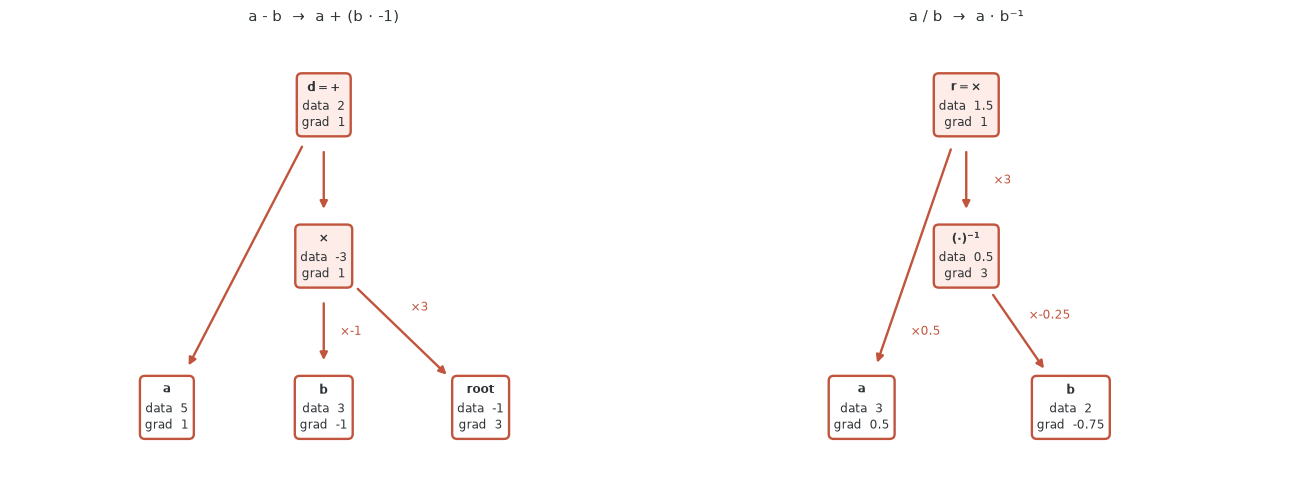

d = 2   a.grad = +1  b.grad = -1
r = 1.5   a.grad = +0.5  b.grad = -0.75   (1/b = +0.5,  -a/b² = -0.75)


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.0))

a, b = Leaf(5.0), Leaf(3.0)
d = a - b
d.wire()
draw_graph(d, {id(a): "a", id(b): "b", id(d): "d"}, ax=ax1,
           title="a - b  →  a + (b · -1)", edge_labels=True)

p, q = Leaf(3.0), Leaf(2.0)
r = p / q
r.wire()
draw_graph(r, {id(p): "a", id(q): "b", id(r): "r"}, ax=ax2,
           title="a / b  →  a · b⁻¹", edge_labels=True)

plt.tight_layout()
plt.show()

print(f"d = {d.data.item():.4g}   a.grad = {a.grad.item():+.4g}  b.grad = {b.grad.item():+.4g}")
av, bv = p.data.item(), q.data.item()
print(f"r = {r.data.item():.4g}   a.grad = {p.grad.item():+.4g}  b.grad = {q.grad.item():+.4g}"
      f"   (1/b = {1 / bv:+.4g},  -a/b² = {-av / bv ** 2:+.4g})")

## Checking the derived rules

Deriving `-` and `/` from `+`, `*` and `**` only pays off if the gradients are
right. Nudge each input by a tiny `ε` and watch how the output moves — no graph,
no chain rule, just arithmetic. If `wire` agrees with that, the derived ops are
right.

(`wire` seeds the apex with **ones**, which makes it the gradient of `out.sum()` —
so that is what the finite difference has to measure.)

In [10]:
def numerical_grad(build, xs, eps=1e-6):
    """Finite-difference ∂sum(out)/∂x for every entry of every input."""
    arrays = [np.asarray(x, dtype=np.float64) for x in xs]
    grads = []
    for i, arr in enumerate(arrays):
        g = np.zeros_like(arr)
        for idx in np.ndindex(arr.shape):
            bumped = []
            for sign in (+1, -1):
                shifted = [x.copy() for x in arrays]
                shifted[i][idx] += sign * eps
                bumped.append(build(*map(Leaf, shifted)).data.sum())
            g[idx] = (bumped[0] - bumped[1]) / (2 * eps)
        grads.append(g)
    return grads


exprs = {
    "a - b":            (lambda a, b: a - b,            [3.0, 5.0]),
    "a / b":            (lambda a, b: a / b,            [3.0, 2.0]),
    "a ** 3":           (lambda a: a ** 3,              [-1.5]),
    "(a - b) / a ** 2": (lambda a, b: (a - b) / a ** 2,  [1.5, -0.5]),
    "a * b - 1  (broadcast)": (lambda a, b: a * b - 1.0, [[[1.0, 2.0], [3.0, 4.0]], [10.0, 100.0]]),
}

for label, (build, xs) in exprs.items():
    roots = [Leaf(x) for x in xs]
    build(*roots).wire()
    expected = numerical_grad(build, xs)
    close = all(np.allclose(r.grad, e, atol=1e-5) for r, e in zip(roots, expected))
    print(f"{label:26} wire {[np.round(r.grad, 3).tolist() for r in roots]}")
    print(f"{'':26} num  {[np.round(e, 3).tolist() for e in expected]}   {'✓' if close else '✗'}")
    assert close

a - b                      wire [1.0, -1.0]
                           num  [1.0, -1.0]   ✓
a / b                      wire [0.5, -0.75]
                           num  [0.5, -0.75]   ✓
a ** 3                     wire [6.75]
                           num  [6.75]   ✓
(a - b) / a ** 2           wire [-0.741, -0.444]
                           num  [-0.741, -0.444]   ✓
a * b - 1  (broadcast)     wire [[[10.0, 100.0], [10.0, 100.0]], [4.0, 6.0]]
                           num  [[[10.0, 100.0], [10.0, 100.0]], [4.0, 6.0]]   ✓


Every derived op matches, including the broadcast one — and not a single new
backward rule was written to get there. `wire` never learned about subtraction or
division; it only ever crosses a `+`, a `*` or a `**`.

## The matrix product

`@` is the first op that is **not** elementwise. It contracts the shared axis:
`(2, 3) @ (3, 4) → (2, 4)`, and the `3` is gone.

So the backward pass cannot just scale the incoming gradient — it has to put that
axis *back*. Below, the shapes tell you how. `a.grad` must come out `(2, 3)`, and
there is exactly one way to build that from `out.grad` and `b`: contract the other
axis, against `b` transposed. The transposes are not something to memorise; they
are the only arrangement that fits.

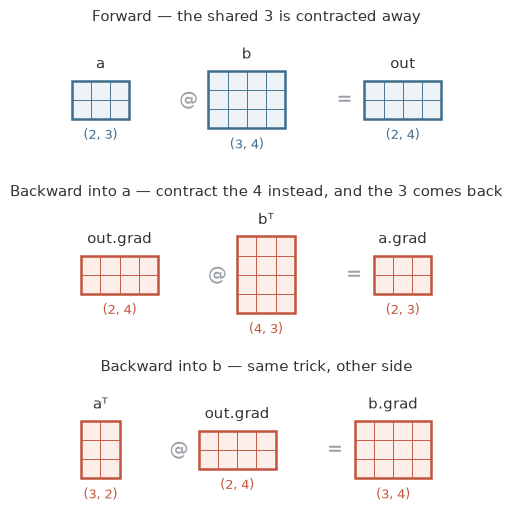

In [11]:
def shape_row(ax, items, color, fill, unit=0.3, gap=0.62):
    """Draw a row of matrix outlines: (rows, cols, label) items, or a separator."""
    x = 0.0
    for item in items:
        if isinstance(item, str):
            ax.text(x + gap / 2, 0, item, ha="center", va="center", fontsize=14, color=MUTED)
            x += gap
            continue
        rows, cols, label = item
        w, h = cols * unit, rows * unit
        for i in range(rows):  # the cells, to make the shape countable
            for j in range(cols):
                ax.add_patch(Rectangle((x + j * unit, h / 2 - (i + 1) * unit), unit, unit,
                                       fc=fill, ec=color, lw=0.7, alpha=0.85))
        ax.add_patch(Rectangle((x, -h / 2), w, h, fc="none", ec=color, lw=1.8))
        ax.text(x + w / 2, h / 2 + 0.14, label, ha="center", va="bottom", fontsize=10.5, color=INK)
        ax.text(x + w / 2, -h / 2 - 0.14, f"({rows}, {cols})", ha="center", va="top",
                fontsize=9.5, color=color)
        x += w + gap
    ax.set_xlim(-0.25, x - gap + 0.25)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")
    ax.axis("off")


fig, axes = plt.subplots(3, 1, figsize=(9, 5.4))

shape_row(axes[0], [(2, 3, "a"), "@", (3, 4, "b"), "=", (2, 4, "out")], FWD, FWD_FILL)
shape_row(axes[1], [(2, 4, "out.grad"), "@", (4, 3, "bᵀ"), "=", (2, 3, "a.grad")], BWD, BWD_FILL)
shape_row(axes[2], [(3, 2, "aᵀ"), "@", (2, 4, "out.grad"), "=", (3, 4, "b.grad")], BWD, BWD_FILL)

axes[0].set_title("Forward — the shared 3 is contracted away", fontsize=10.5, color=INK, pad=6)
axes[1].set_title("Backward into a — contract the 4 instead, and the 3 comes back",
                  fontsize=10.5, color=INK, pad=6)
axes[2].set_title("Backward into b — same trick, other side", fontsize=10.5, color=INK, pad=6)
plt.tight_layout()
plt.show()

### A layer, and a shared weight

`x @ w + b` is a `Linear` layer — we can build one now, months before we have a
`Linear` class. Push a **batch** through it and the two shape mechanics appear
side by side: `@` contracts the features, and `b` broadcasts across the examples.

Every example uses the *same* `w` and `b`, so their gradients sum over the batch —
which is exactly what makes a batch a batch. To see that plainly, feed the layer
the **same example** repeated `n` times. The parameter gradients keep their shape
and come out exactly `n` times the single-example gradient, while `x.grad` grows a
row per example instead.

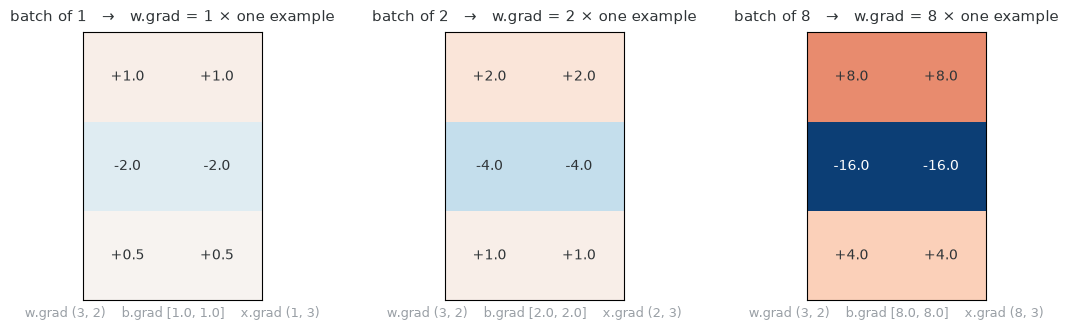

In [12]:
rng = np.random.default_rng(0)
row = np.array([1.0, -2.0, 0.5])   # one example, repeated n times
w0, b0 = rng.normal(size=(3, 2)), rng.normal(size=2)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, n in zip(axes, (1, 2, 8)):
    x, w, b = Leaf(np.tile(row, (n, 1))), Leaf(w0), Leaf(b0)
    (x @ w + b).wire()
    # diverging, centred on zero: hue carries the sign, intensity the size
    ax.imshow(w.grad, cmap="RdBu_r", vmin=-17, vmax=17)
    for (i, j), v in np.ndenumerate(w.grad):
        ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=10,
                color="white" if abs(v) > 10 else INK)
    ax.set_title(f"batch of {n}   →   w.grad = {n} × one example",
                 fontsize=10.5, color=INK, pad=8)
    ax.set_xlabel(f"w.grad {w.grad.shape}    b.grad {b.grad.tolist()}"
                  f"    x.grad {x.grad.shape}", fontsize=9, color=MUTED)
    ax.set_xticks([])
    ax.set_yticks([])
    assert w.grad.shape == w0.shape and b.grad.shape == b0.shape
    np.testing.assert_allclose(w.grad, n * np.tile(row[:, None], (1, 2)))
plt.tight_layout()
plt.show()

And the same finite-difference check, now on graphs whose shapes never line up
elementwise. If `@`'s transposes were the wrong way round, no amount of luck would
get these to agree.

In [ ]:
x0 = [[1.0, 2.0, -1.0], [0.5, -2.0, 3.0]]
w0 = [[1.0, -1.0], [2.0, 0.5], [-0.5, 1.5]]
b0 = [0.25, -0.75]

exprs = {
    "a @ b":          (lambda a, b: a @ b, [x0, w0]),
    "x @ w + b":      (lambda x, w, b: x @ w + b, [x0, w0, b0]),
    "(x @ w) ** 2":   (lambda x, w: (x @ w) ** 2, [x0, w0]),
}

for label, (build, xs) in exprs.items():
    roots = [Leaf(x) for x in xs]
    build(*roots).wire()
    ok = all(np.allclose(r.grad, e, atol=1e-5) and r.grad.shape == r.data.shape
             for r, e in zip(roots, numerical_grad(build, xs)))
    shapes = "  ".join(f"{r.grad.shape}" for r in roots)
    print(f"{label:14} grads {shapes:24} {'✓' if ok else '✗'}")
    assert ok

Elementwise ops broadcast, `@` contracts, and both hand back a gradient shaped
exactly like the node it belongs to. That invariant is what lets an optimizer do
`data -= lr * grad` without ever thinking about shapes.

Next: layers, built out of these pieces.